# 🏦 Consumer Complaint Classification 

An End-to-End project to automatically classify customer complaints using:
- **SimpleRNN** / **LSTM** / **GRU** (Built from scratch using Keras)
- **Fine-tuned Transformer** (DistilBERT via Hugging Face))
- **Professional** **Gradio App**for **deployment and live testing**

💡 **Tip: It is highly recommended to run this notebook on Kaggle (Runtime → Change runtime type → GPU), especially for the Transformer fine-tuning step**.

## Notebook Workflow:
1. Installing Libraries
2. Data Loading and Exploration (EDA)
3. Text Preprocessing
4. Analyzing and Handling Class Imbalance
5. Tokenization + Padding
6. Building and Training SimpleRNN / LSTM / GRU
7. Fine-tuning the Transformer (DistilBERT)
8. Evaluating and Comparing the Four Models
9. Testing the Best Model on New Complaints
10. Running the Gradio App

## 1️⃣ Installing Libraries

In [7]:
!pip install -q tensorflow scikit-learn pandas numpy nltk matplotlib seaborn \
    transformers datasets accelerate torch gradio imbalanced-learn joblib

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("✅ Libraries installed")

✅ Libraries installed


# Load Data

In [49]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv")

In [50]:
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


# Check Data Information

# Check Nulls

In [39]:
df.isnull().sum()

Unnamed: 0     0
product        0
narrative     10
dtype: int64

In [40]:
df[df["narrative"].isna()]

,Unnamed: 0,product,narrative
1089,1089,credit_reporting,NaN
3954,3954,credit_reporting,NaN
3955,3955,credit_reporting,NaN
29690,29690,credit_reporting,NaN
139436,139436,debt_collection,NaN
151052,151052,debt_collection,NaN
154494,154494,credit_reporting,NaN
156902,156902,retail_banking,NaN
158538,158538,credit_reporting,NaN
159503,159503,credit_reporting,NaN


Handling Missing Values
The missing values are found only in the **narrative** column, which contains the complaint text.
Since these missing records represent only a very small fraction of the dataset (10 out of 162,421 records, approximately 0.006%), removing them will have a negligible impact on the dataset while ensuring that all training samples contain valid text.

Therefore, we will drop rows with missing complaint narratives.

In [41]:
# Remove rows with missing complaint narratives
df.dropna(subset=["narrative"], inplace=True)

# Reset the index after removing rows
df.reset_index(drop=True, inplace=True)
df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
162406,162416,debt_collection,name
162407,162417,credit_card,name
162408,162418,debt_collection,name
162409,162419,credit_card,name


In [43]:
df["narrative"][df["narrative"] == "name"].value_counts()

df[df["narrative"].str.lower().str.strip() == "name"]

,Unnamed: 0,product,narrative
162405,162415,debt_collection,name
162406,162416,debt_collection,name
162407,162417,credit_card,name
162408,162418,debt_collection,name
162409,162419,credit_card,name
162410,162420,credit_reporting,name


In [44]:
df[df["narrative"].str.lower().str.strip() == "name"].shape

(6, 3)

In [45]:
# Remove rows where the complaint text is only "name"
df = df[df["narrative"].str.lower().str.strip() != "name"]

# Reset index
df.reset_index(drop=True, inplace=True)
df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
162400,162410,credit_reporting,zales comenity bank closed sold account report...
162401,162411,retail_banking,zelle suspended account without cause banking ...
162402,162412,debt_collection,zero contact made debt supposedly resolved fou...
162403,162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...


In [51]:
df.drop(columns="Unnamed: 0" , axis= 1 , inplace= True)

In [13]:
df.columns.to_list()

['product', 'narrative']

In [14]:
df.shape

(162421, 2)

In [15]:
df.info

<bound method DataFrame.info of                  product                                          narrative
0            credit_card  purchase order day shipping amount receive pro...
1            credit_card  forwarded message date tue subject please inve...
2         retail_banking  forwarded message cc sent friday pdt subject f...
3       credit_reporting  payment history missing credit report speciali...
4       credit_reporting  payment history missing credit report made mis...
...                  ...                                                ...
162416   debt_collection                                               name
162417       credit_card                                               name
162418   debt_collection                                               name
162419       credit_card                                               name
162420  credit_reporting                                               name

[162421 rows x 2 columns]>

In [16]:
import random
import pandas as pd
from pathlib import Path
random.seed(42)

DATA_PATH = "/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv"
TEXT_COL = "narrative"
LABEL_COL = "product"

df = pd.read_csv(DATA_PATH, low_memory=False)[[TEXT_COL, LABEL_COL]].dropna()
df = df.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})
print(f"Total rows: {len(df)}")
df.head()

Total rows: 162411


,text,label
0,purchase order day shipping amount receive pro...,credit_card
1,forwarded message date tue subject please inve...,credit_card
2,forwarded message cc sent friday pdt subject f...,retail_banking
3,payment history missing credit report speciali...,credit_reporting
4,payment history missing credit report made mis...,credit_reporting


In [17]:
df.describe(include="O")

,text,label
count,162411,162411
unique,124472,5
top,victim identity notified collection creditor s...,credit_reporting
freq,739,91172


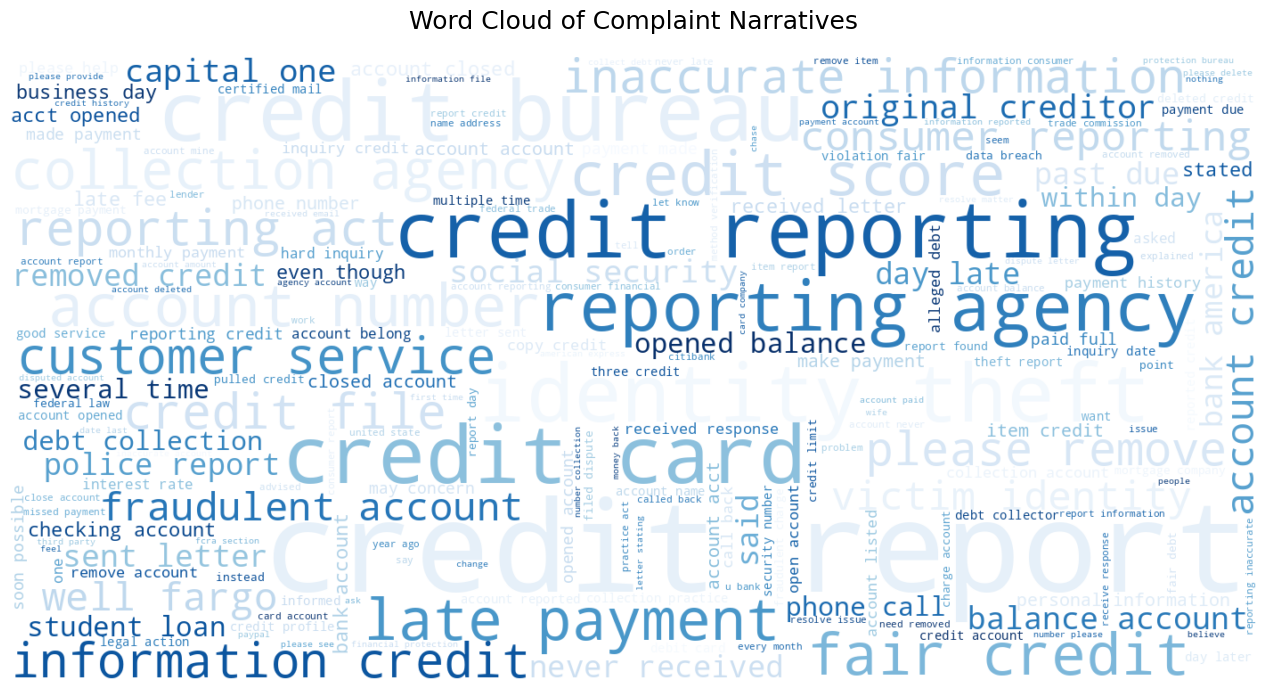

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Combine all complaint narratives
text = " ".join(df["narrative"].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Blues",
    max_words=200,
    contour_width=1,
    contour_color="steelblue",
    random_state=42
).generate(text)

# Plot
plt.figure(figsize=(15, 7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud of Complaint Narratives",
    fontsize=18,
    pad=20
)

plt.tight_layout()

plt.show()

📊 Class distribution:
label
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


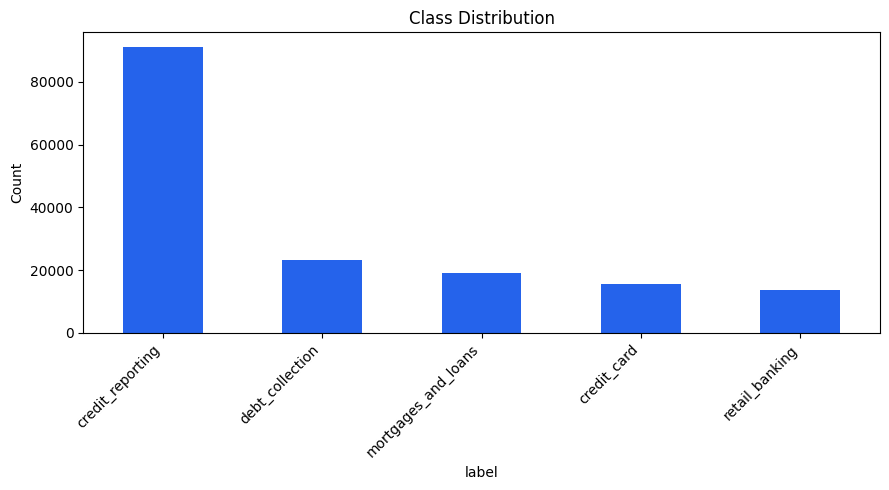

In [18]:
# explore class distribution
import matplotlib.pyplot as plt

TOP_N_CLASSES = 10
top_classes = df["label"].value_counts().nlargest(TOP_N_CLASSES).index
df = df[df["label"].isin(top_classes)].reset_index(drop=True)

print("📊 Class distribution:")
print(df["label"].value_counts())

plt.figure(figsize=(9, 5))
df["label"].value_counts().plot(kind="bar", color="#2563eb")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3️⃣ (Text Preprocessing)

In [19]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"x{2,}", " ", text)              # CFPB redacted placeholders "XXXX"
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)            # remove numbers/punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df = df[df["word_count"] >= 3].reset_index(drop=True)

print("Before:", df["text"].iloc[0])
print("\n" + "="*80 + "\n")
print("After :", df["clean_text"].iloc[0])
df[["text", "clean_text"]].head()

Before: purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing 

,text,clean_text
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


## 4️⃣  ( Analyzing and Handling Class Imbalance)

In [20]:
RANDOM_STATE = 42

def handle_class_imbalance(df, max_ratio=3.0):
    counts = df["label"].value_counts()
    min_count = counts.min()
    cap = int(min_count * max_ratio)
    parts = []
    for label, group in df.groupby("label"):
        if len(group) > cap:
            group = group.sample(cap, random_state=RANDOM_STATE)
        parts.append(group)
    return pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df_balanced = handle_class_imbalance(df)
print(f"Before: {len(df)} rows -> After balancing: {len(df_balanced)} rows")
df_balanced["label"].value_counts()
df

Before: 162016 rows -> After balancing: 111670 rows


,text,label,clean_text,word_count
0,purchase order day shipping amount receive pro...,credit_card,purchase order day shipping amount receive pro...,226
1,forwarded message date tue subject please inve...,credit_card,forwarded message date tue subject please inve...,132
2,forwarded message cc sent friday pdt subject f...,retail_banking,forwarded message cc sent friday pdt subject f...,173
3,payment history missing credit report speciali...,credit_reporting,payment history missing credit report speciali...,131
4,payment history missing credit report made mis...,credit_reporting,payment history missing credit report made mis...,123
...,...,...,...,...
162011,zales comenity bank closed sold account report...,credit_reporting,zales comenity bank closed sold account report...,69
162012,zelle suspended account without cause banking ...,retail_banking,zelle suspended account without cause banking ...,17
162013,zero contact made debt supposedly resolved fou...,debt_collection,zero contact made debt supposedly resolved fou...,25
162014,zillow home loan nmls nmls actual quote provid...,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...,16


## 5️⃣ Label Encoding + Train/Val/Test Split

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df_balanced["label_id"] = le.fit_transform(df_balanced["label"])
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

X_temp, X_test, y_temp, y_test = train_test_split(
    df_balanced["clean_text"].values, df_balanced["label_id"].values,
    test_size=0.15, random_state=RANDOM_STATE, stratify=df_balanced["label_id"].values
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=RANDOM_STATE, stratify=y_temp
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Classes (5): ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']
Train: 80681 | Val: 14238 | Test: 16751


## 6️⃣ Tokenization + Padding

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB_SIZE = 20000
MAX_SEQ_LEN = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")

X_train_pad = to_padded(X_train)
X_val_pad = to_padded(X_val)
X_test_pad = to_padded(X_test)

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index)) + 1
print(f"Vocabulary size: {len(tokenizer.word_index)} | Padded shape: {X_train_pad.shape}")

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
classes_arr = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes_arr, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes_arr, weights)}
print("Class weights:", class_weight_dict)

Vocabulary size: 36683 | Padded shape: (80681, 150)
Class weights: {0: 1.4349666518452646, 1: 0.551005634283763, 2: 0.9677461916756627, 3: 1.176450860309128, 4: 1.6531298022743572}


In [23]:
print("Vocabulary Size:", len(tokenizer.word_index) + 1 )

top_20_words = list(tokenizer.word_index.items())[:20]

pd.DataFrame(
    top_20_words,
    columns=["Word", "Index"]
)

Vocabulary Size: 36684


,Word,Index
0,<OOV>,1
1,account,2
2,credit,3
3,payment,4
4,report,5
5,information,6
6,would,7
7,time,8
8,loan,9
9,bank,10


## 7️⃣ Models Buliding: SimpleRNN / LSTM / GRU

 `** mask_zero=True`**: بما إن الشكاوى القصيرة بتتحشى (padding) لطول ثابت (150)،
لو الـ Embedding مفعّلش `mask_zero=True`، الموديل (خصوصًا LSTM/GRU) هيفضل يعالج عشرات الخطوات
من الـ padding بعد النص الحقيقي، وده بيمسح الإشارة المفيدة تمامًا ويخلي الموديل عالق عند دقة عشوائية.


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout,
    Bidirectional, SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

EMBEDDING_DIM = 128

def build_simple_rnn(vocab_size, max_len, num_classes):
    
    model = Sequential(name="SimpleRNN_Model")
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True))
    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(SimpleRNN(64, return_sequences=True)))
    model.add(SimpleRNN(32))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation="relu", kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(vocab_size, max_len, num_classes):
    model = Sequential(name="LSTM_Model")
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True))
    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(LSTM(32))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation="relu", kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_gru(vocab_size, max_len, num_classes):
    model = Sequential(name="GRU_Model")
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True))
    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(GRU(64, return_sequences=True)))
    model.add(GRU(32))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation="relu", kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

MODEL_BUILDERS = {"SimpleRNN": build_simple_rnn, "LSTM": build_lstm, "GRU": build_gru}
build_simple_rnn(vocab_size, MAX_SEQ_LEN, num_classes).summary()

I0000 00:00:1784412812.808229      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784412812.814575      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8️⃣ Train  3 Models (SimpleRNN / LSTM / GRU)

In [25]:
import os, json
os.makedirs("models", exist_ok=True)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

EPOCHS = 20
BATCH_SIZE = 64
histories = {}
trained_models = {}

for name, builder in MODEL_BUILDERS.items():
    print("\n" + "="*70, f"\n🚀 Training {name} ...\n" + "="*70)
    model = builder(vocab_size, MAX_SEQ_LEN, num_classes)
    ckpt_path = f"models/{name.lower()}_model.keras"
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]
    history = model.fit(
        X_train_pad, y_train, validation_data=(X_val_pad, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight_dict,
        callbacks=callbacks, verbose=2,
    )
    test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"✅ {name} — Test Accuracy: {test_acc:.4f}")
    histories[name] = history.history
    trained_models[name] = model


🚀 Training SimpleRNN ...
Epoch 1/20


I0000 00:00:1784412835.818758     172 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1261/1261 - 59s - 47ms/step - accuracy: 0.5735 - loss: 1.1041 - val_accuracy: 0.6870 - val_loss: 0.8831 - learning_rate: 0.0010
Epoch 2/20
1261/1261 - 44s - 35ms/step - accuracy: 0.5446 - loss: 1.1699 - val_accuracy: 0.5324 - val_loss: 1.1878 - learning_rate: 0.0010
Epoch 3/20
1261/1261 - 44s - 35ms/step - accuracy: 0.4712 - loss: 1.2682 - val_accuracy: 0.4081 - val_loss: 1.4825 - learning_rate: 0.0010
Epoch 4/20
1261/1261 - 44s - 35ms/step - accuracy: 0.5055 - loss: 1.2178 - val_accuracy: 0.7028 - val_loss: 0.8329 - learning_rate: 5.0000e-04
Epoch 5/20
1261/1261 - 44s - 35ms/step - accuracy: 0.6729 - loss: 0.9417 - val_accuracy: 0.6443 - val_loss: 0.9313 - learning_rate: 5.0000e-04
Epoch 6/20
1261/1261 - 44s - 35ms/step - accuracy: 0.7046 - loss: 0.8674 - val_accuracy: 0.7203 - val_loss: 0.8179 - learning_rate: 5.0000e-04
Epoch 7/20
1261/1261 - 44s - 35ms/step - accuracy: 0.6481 - loss: 1.0216 - val_accuracy: 0.6724 - val_loss: 0.9573 - learning_rate: 5.0000e-04
Epoch 8/20
1261/1261 -

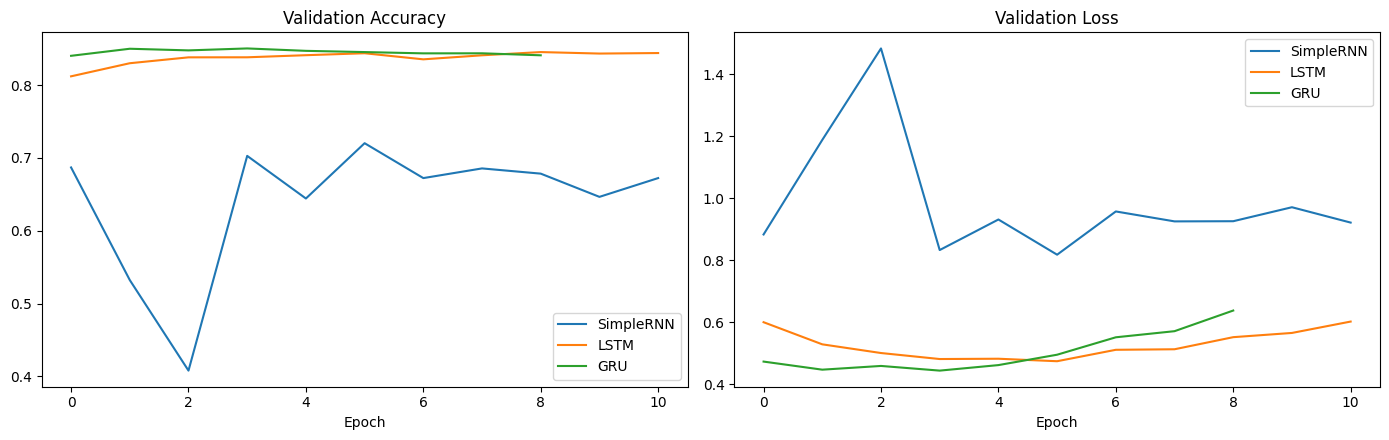

In [26]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in histories.items():
    axes[0].plot(h["val_accuracy"], label=name)
    axes[1].plot(h["val_loss"], label=name)
axes[0].set_title("Validation Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].set_title("Validation Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

## 9️⃣ Fine-tuning الـ Transformer (DistilBERT)




In [31]:
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
TRANSFORMER_MAX_LEN = 128
TRANSFORMER_EPOCHS = 3
TRANSFORMER_BATCH_SIZE = 16

train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df = pd.DataFrame({"text": X_val, "label": y_val})
test_df = pd.DataFrame({"text": X_test, "label": y_test})

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return hf_tokenizer(batch["text"], truncation=True, max_length=TRANSFORMER_MAX_LEN)

train_ds = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
val_ds = Dataset.from_pandas(val_df).map(tokenize_fn, batched=True)
test_ds = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)
transformer_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="models/transformer_model/checkpoints",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,
    per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE,
    num_train_epochs=TRANSFORMER_EPOCHS, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1",
    logging_steps=50, report_to="none", fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=transformer_model, 
    args=training_args,
    train_dataset=train_ds, 
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("🚀 Fine-tuning DistilBERT ...")
trainer.train()

transformer_test_results = trainer.evaluate(test_ds)
print(transformer_test_results)

trainer.save_model("models/transformer_model")
hf_tokenizer.save_pretrained("models/transformer_model")
print("✅ Transformer saved to models/transformer_model")

Map:   0%|          | 0/80681 [00:00<?, ? examples/s]

Map:   0%|          | 0/14238 [00:00<?, ? examples/s]

Map:   0%|          | 0/16751 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.792256236076355, 'eval_accuracy': 0.8676496925556684, 'eval_precision': 0.867629196520113, 'eval_recall': 0.8676496925556684, 'eval_f1': 0.8675558359227161, 'eval_runtime': 42.1895, 'eval_samples_per_second': 397.041, 'eval_steps_per_second': 12.42, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Transformer saved to models/transformer_model


## 🔟 Evaluating and Comparing the Four Models


=== SimpleRNN ===
                     precision    recall  f1-score   support

        credit_card       0.53      0.70      0.61      2334
   credit_reporting       0.87      0.73      0.79      6080
    debt_collection       0.67      0.77      0.72      3462
mortgages_and_loans       0.72      0.64      0.68      2848
     retail_banking       0.74      0.74      0.74      2027

           accuracy                           0.72     16751
          macro avg       0.71      0.72      0.71     16751
       weighted avg       0.74      0.72      0.72     16751



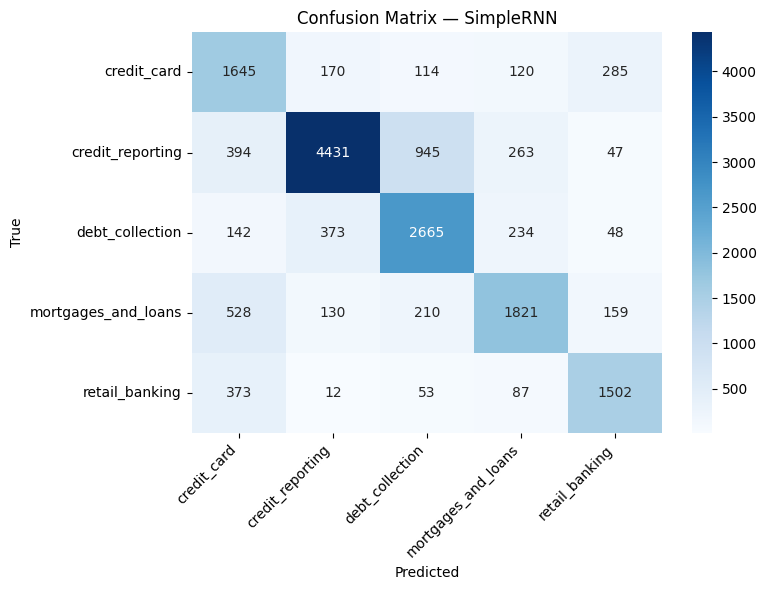


=== LSTM ===
                     precision    recall  f1-score   support

        credit_card       0.78      0.82      0.80      2334
   credit_reporting       0.91      0.83      0.87      6080
    debt_collection       0.82      0.83      0.82      3462
mortgages_and_loans       0.81      0.89      0.85      2848
     retail_banking       0.85      0.89      0.87      2027

           accuracy                           0.85     16751
          macro avg       0.84      0.85      0.84     16751
       weighted avg       0.85      0.85      0.85     16751



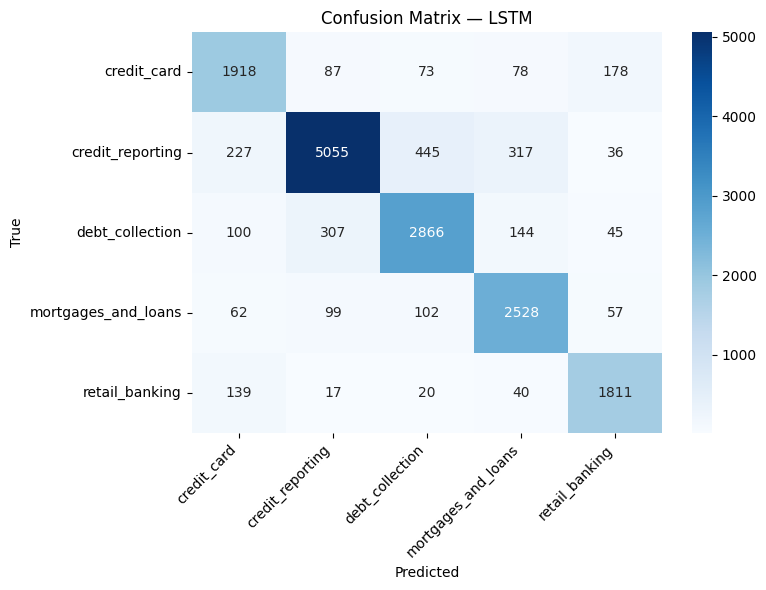


=== GRU ===
                     precision    recall  f1-score   support

        credit_card       0.77      0.85      0.81      2334
   credit_reporting       0.92      0.83      0.87      6080
    debt_collection       0.82      0.83      0.83      3462
mortgages_and_loans       0.82      0.90      0.86      2848
     retail_banking       0.87      0.87      0.87      2027

           accuracy                           0.85     16751
          macro avg       0.84      0.86      0.85     16751
       weighted avg       0.85      0.85      0.85     16751



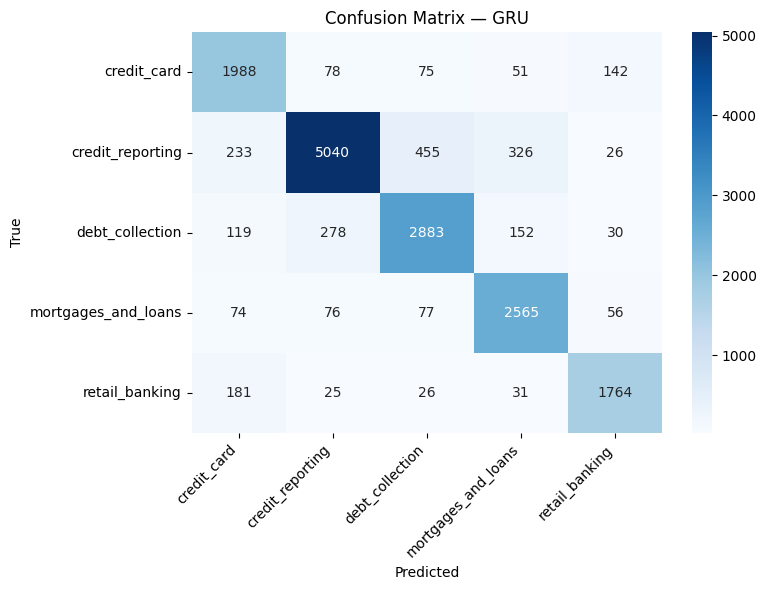


=== Transformer (DistilBERT) ===
                     precision    recall  f1-score   support

        credit_card       0.81      0.84      0.82      2334
   credit_reporting       0.89      0.90      0.89      6080
    debt_collection       0.85      0.82      0.83      3462
mortgages_and_loans       0.87      0.87      0.87      2848
     retail_banking       0.88      0.90      0.89      2027

           accuracy                           0.87     16751
          macro avg       0.86      0.86      0.86     16751
       weighted avg       0.87      0.87      0.87     16751



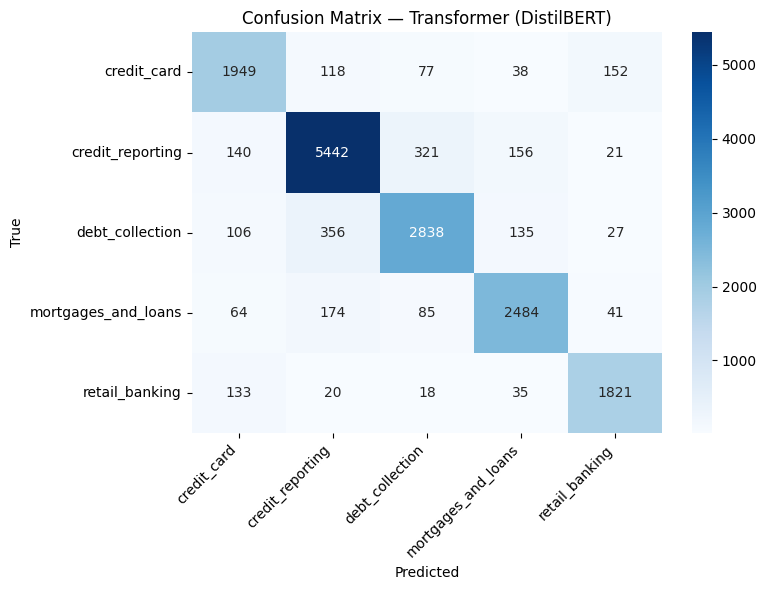

,Model,Accuracy,Precision,Recall,F1-score
0,Transformer (DistilBERT),0.867650,0.867629,0.867650,0.867556
1,GRU,0.850099,0.854326,0.850099,0.850767
2,LSTM,0.846397,0.849271,0.846397,0.846813
3,SimpleRNN,0.720196,0.738547,0.720196,0.724423


In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

classes = list(le.classes_)
results = []

def plot_cm(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# --- RNN family ---
for name, model in trained_models.items():
    probs = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))
    plot_cm(y_test, y_pred, name)
    results.append({"Model": name, "Accuracy": acc, "Precision": precision, "Recall": recall, "F1-score": f1})

# --- Transformer ---
device = "cuda" if torch.cuda.is_available() else "cpu"
transformer_model.to(device).eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test), 32):
        batch = X_test[i:i+32]
        enc = hf_tokenizer(list(batch), truncation=True, padding=True, max_length=TRANSFORMER_MAX_LEN, return_tensors="pt").to(device)
        logits = transformer_model(**enc).logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
y_pred_t = np.array(preds)
acc = accuracy_score(y_test, y_pred_t)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_t, average="weighted", zero_division=0)
print("\n=== Transformer (DistilBERT) ===")
print(classification_report(y_test, y_pred_t, target_names=classes, zero_division=0))
plot_cm(y_test, y_pred_t, "Transformer (DistilBERT)")
results.append({"Model": "Transformer (DistilBERT)", "Accuracy": acc, "Precision": precision, "Recall": recall, "F1-score": f1})

comparison_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
comparison_df

/tmp/ipykernel_58/986820835.py:13: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


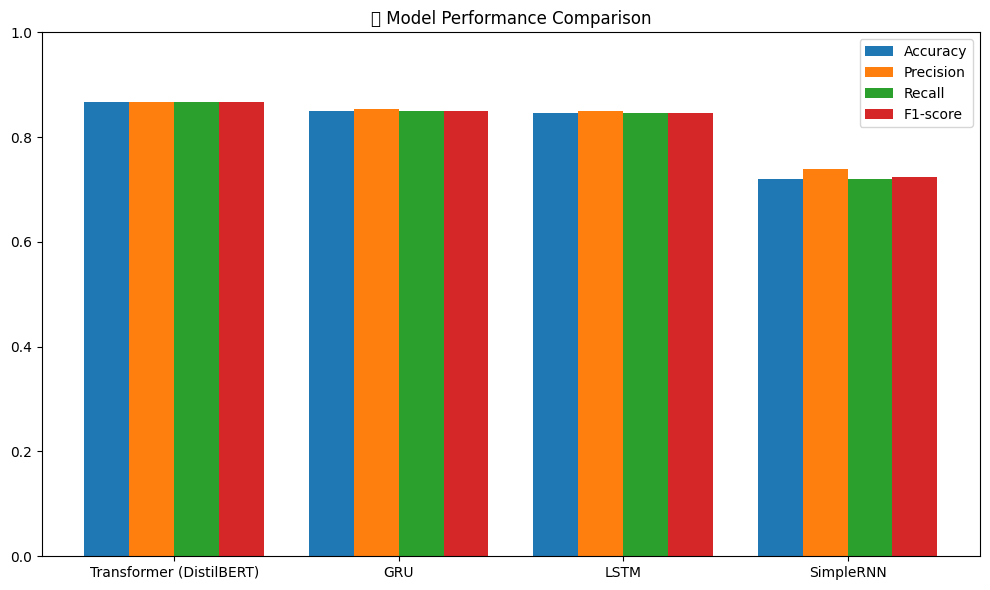

🥇 Best Model: Transformer (DistilBERT)


In [33]:
# 📊 Final Model Comparison Chart
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.2
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(comparison_df["Model"])
ax.set_ylim(0, 1)
ax.set_title("🏆 Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]["Model"]
print(f"🥇 Best Model: {best_model_name}")

## 1️⃣1️⃣ Testing the Best Model on New Complaints

In [34]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(tokenizer, "models/tokenizer.pkl")
joblib.dump(le, "models/label_encoder.pkl")
with open("models/config.json", "w") as f:
    json.dump({"max_vocab_size": MAX_VOCAB_SIZE, "max_seq_len": MAX_SEQ_LEN,
               "num_classes": num_classes, "classes": classes}, f, indent=2)

def predict_new_complaint(text, model_name="LSTM", top_k=3):
    cleaned = clean_text(text)
    if model_name == "Transformer (DistilBERT)":
        enc = hf_tokenizer(text, truncation=True, padding=True, max_length=TRANSFORMER_MAX_LEN, return_tensors="pt")
        with torch.no_grad():
            probs = torch.softmax(transformer_model(**enc).logits, dim=1).squeeze().numpy()
    else:
        seq = tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
        probs = trained_models[model_name].predict(padded, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(classes[i], float(probs[i])) for i in top_idx]

sample_complaint = "I have been charged an overdraft fee multiple times even though I always kept enough balance in my account."
for r in predict_new_complaint(sample_complaint, model_name=best_model_name if best_model_name in trained_models else "LSTM"):
    print(f"{r[0]:35s} -> {r[1]*100:.2f}%")

retail_banking                      -> 66.34%
mortgages_and_loans                 -> 15.47%
credit_card                         -> 12.99%


## 1️⃣2️⃣ Running the Gradio App




In [56]:
import gradio as gr

EXAMPLES = [
    ["I was charged twice for the same purchase on my credit card and the bank refuses to refund me.", "SimpleRNN"],
    ["My mortgage servicer started foreclosure even though I have been making my payments on time.", "LSTM"],
    ["A debt collector keeps calling me multiple times a day about a debt that isn't even mine.", "GRU"],
]
available_models = list(trained_models.keys()) + (["Transformer (DistilBERT)"] if "transformer_model" in dir() else [])

CUSTOM_CSS = """
.gradio-container { font-family: 'Segoe UI', 'Inter', sans-serif !important;
    background: linear-gradient(135deg, #0f172a 0%, #1e293b 100%) !important; }
#header h1 { font-size: 2.1rem; background: linear-gradient(90deg, #60a5fa, #a78bfa);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent; font-weight: 800; }
#predict-btn { background: linear-gradient(90deg, #2563eb, #7c3aed) !important; color: white !important;
    font-weight: 700 !important; border: none !important; border-radius: 12px !important; }
footer {visibility: hidden}
"""

THEME = gr.themes.Soft(primary_hue="blue", secondary_hue="violet", neutral_hue="slate")

def plot_top_k(top_results):
    labels = [r[0] for r in top_results][::-1]
    scores = [r[1]*100 for r in top_results][::-1]
    fig, ax = plt.subplots(figsize=(6, 3))
    fig.patch.set_alpha(0); ax.set_facecolor("none")
    bars = ax.barh(labels, scores, color=plt.cm.Blues([0.9-0.2*i for i in range(len(scores))]))
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2, f"{score:.1f}%", va="center", fontsize=10)
    ax.set_xlim(0, 105); ax.set_title("Top Predictions")
    plt.tight_layout()
    return fig

def classify_complaint(text, model_name):
    if not text or not text.strip():
        return "⚠️ يرجى إدخال نص الشكوى", "", None
    top_results = predict_new_complaint(text, model_name=model_name, top_k=3)
    label, confidence = top_results[0]
    result_html = f"<div style=\'padding:14px;border-radius:12px;background:rgba(37,99,235,0.12);\'><div style=\'color:#93c5fd;\'>الفئة المتوقعة</div><div style=\'color:#f8fafc;font-size:1.5rem;font-weight:800;\'>{label}</div></div>"
    confidence_html = f"<div style=\'margin-top:10px;text-align:center;color:#34d399;font-weight:700;\'>✅ Confidence: {confidence*100:.2f}%</div>"
    return result_html, confidence_html, plot_top_k(top_results)

with gr.Blocks(theme=THEME, css=CUSTOM_CSS, title="Consumer Complaint Classifier") as demo:
    with gr.Column(elem_id="header"):
        gr.Markdown("# 🏦 Consumer Complaint Classifier")
        gr.Markdown("Automated Customer Complaint Classification System Using AI")
    with gr.Row():
        with gr.Column():
            complaint_input = gr.Textbox(label="Complaint narrative", lines=8, placeholder="Enter your complaint text here....")
            model_choice = gr.Radio(choices=available_models, value=available_models[0], label="🧠Select Model")
            predict_btn = gr.Button("🔍 Classify Complaint", elem_id="predict-btn")
            gr.Examples(examples=[e for e in EXAMPLES if e[1] in available_models], inputs=[complaint_input, model_choice])
        with gr.Column():
            result_output = gr.HTML()
            confidence_output = gr.HTML()
            chart_output = gr.Plot()
    predict_btn.click(classify_complaint, [complaint_input, model_choice], [result_output, confidence_output, chart_output])

demo.launch(share=True) 

/tmp/ipykernel_58/2218000180.py:43: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=THEME, css=CUSTOM_CSS, title="Consumer Complaint Classifier") as demo:
/tmp/ipykernel_58/2218000180.py:43: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=THEME, css=CUSTOM_CSS, title="Consumer Complaint Classifier") as demo:


* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://05b270f9abf24b19c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^